In [19]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

In [20]:
# Load IMDB dataset (already integer encoded)
# num_words = top most frequent words
vocab_size = 80000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [21]:
# Make all sequences same length
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [22]:
def build_lstm():
   model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(1, activation='sigmoid')
])
   return model

model = build_lstm()

In [23]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

print("Training LSTM model...")

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Training LSTM model...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 94s 234ms/step - accuracy: 0.7586 - loss: 0.4984 - val_accuracy: 0.8222 - val_loss: 0.4088
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 90s 229ms/step - accuracy: 0.8704 - loss: 0.3230 - val_accuracy: 0.8466 - val_loss: 0.3833
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 227ms/step - accuracy: 0.8988 - loss: 0.2595 - val_accuracy: 0.8442 - val_loss: 0.3841


In [25]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8466 - loss: 0.3833
Test Accuracy: 0.8465999960899353


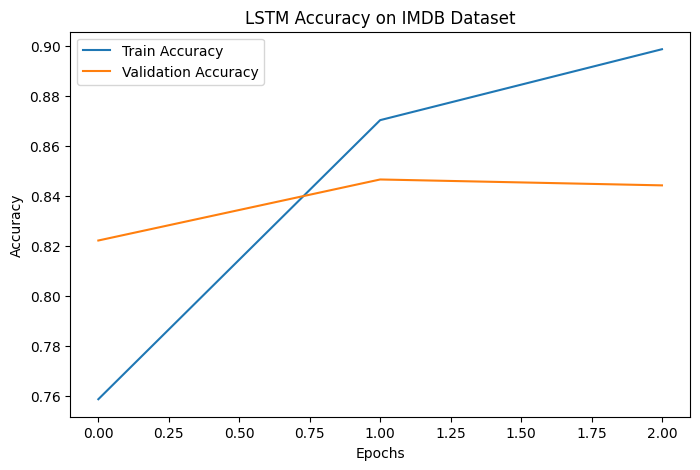

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy on IMDB Dataset")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()